<a href="https://colab.research.google.com/github/Dickmanns/ai_project_1/blob/main/02_mdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install mushroom_rl
!pip3 install pynput
from IPython.display import clear_output
clear_output()

# Online Practical Sessions - Coding an MDP:
The MDP represents the scheme of interaction of the agent with the environment

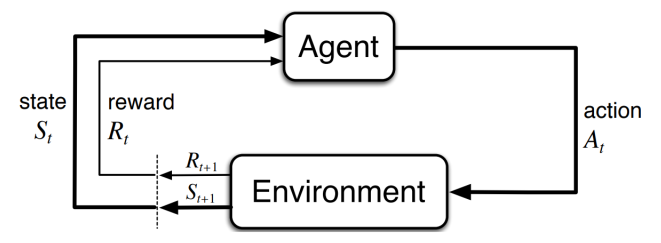

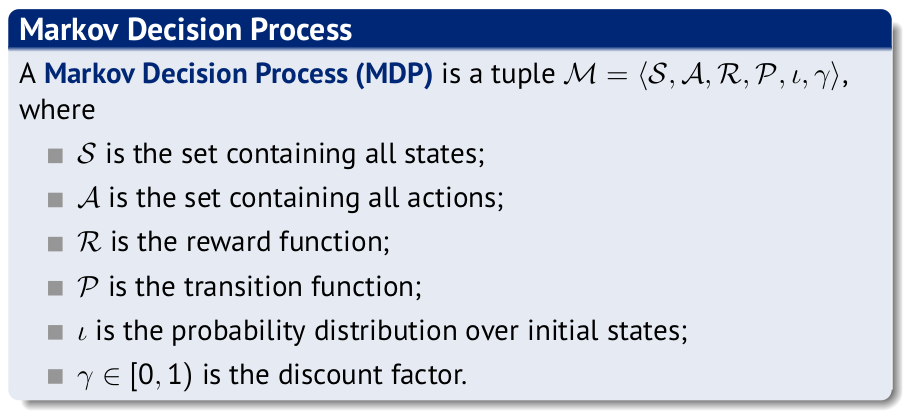

We are going to create a simple grid world environment using MushroomRL classes.

In [ ]:
import numpy as np

from mushroom_rl.utils.viewer import Viewer
from mushroom_rl.environments import FiniteMDP #https://github.com/MushroomRL/mushroom-rl/blob/dev/mushroom_rl/environments/finite_mdp.py

Example of a grid world environment:

The environment is a mini grid with bramble bushes that hurt the agent if crossed.
    The agent is spawn in the bottom-left quadrant of the grid and the goal is in the top-right corner.
    There is a pair of shears in the top-left corner that allows the agent to prune the bushes.
    The agent can move in the four directions.
    The episode ends when the agent reaches the goal.

In [ ]:
class ExampleGridWorldEnv(FiniteMDP):
    """
    Example of environment class construction and usage of Mushroom FiniteMDP class
    It is a mini grid environment with bramble bushes that hurt the actor if crossed.
    The actor is spawn in the bottom-left quadrant of the grid and the goal is in the top-right corner.
    There is a pair of shears in top-left corner that allows the actor to prune the bushes.
    The agent can move in the four directions.
    The episode ends when the agent reaches the goal.
    """
    def __init__(self, size=(10, 10), n_obs=10, gamma=0.99, horizon=100, prob=1):
        # initialize the base class

        # set the size of the grid
        self._size = size

        ###
        # Obstacles positions
        self.n_obs = n_obs
        self.obstacle_x_idx_B = np.random.randint(1, self._size[0]-1, n_obs)
        self.obstacle_y_idx_B = np.random.randint(1, self._size[1]-1, n_obs)
        ###

        # set the probability of success for each action
        self.prob = prob

        # change in coordinates for each action
        self.directions = [[0, 1], [-1, 0], [0, -1], [1, 0]]

        # define a viewer for visualization
        self._viewer = Viewer(self._size[0]+1, self._size[1]+1, 500, 500)

        # record last action to use it in the visualization
        self._last_action = [0]

        # build two finite MDPs for the 2 states of the bushes
        # initial state distribution
        mu = self.initialize_state_distribution()
        # transition matrix
        p = self.compute_probabilities(self.prob)
        # reward matrix
        r = self.compute_rewards()

        # call the super class
        super().__init__(p, r, mu, gamma, horizon)

        # reset the environment
        self.reset()

    def initialize_state_distribution(self):
        # Create the initial state distribution.

        # Initialize the state distribution
        mu = ### TODO ###

        # fill the bottom left quarter with 1 for s=0
        ### TODO ###

        # normalize the distribution
        mu = ### TODO ###

        # flatten the distribution
        mu = mu.flatten()

        return mu

    def state_(self, s, i_a, j_a):
        # Get state index from agent position.

        idx = s*self._size[0]*self._size[1]+i_a*self._size[1]+j_a

        # Notice that:
        #     s = idx // (self._size[0]*self._size[1])
        #     i_a = (idx % (self._size[1]*self._size[1])[0] // self._size[1]
        #     j_a = (idx % (self._size[1]*self._size[1])[0] % self._size[1]

        return idx

    def compute_probabilities(self, prob):
        # Compute the transition probabilities.

        # Initialize transition probability matrix with 0
        # The size = (observation space shape) x (action space shape) x (observation space shape)
        p = ### TODO ###

        # iterate over the states and fill the transition probability matrix
        for s in range(2):
            for i_a in range(self._size[0]):
                for j_a in range(self._size[1]):

                    # to set the goal as a terminal state
                    ### TODO ###

                    # skip if you collect the shears
                    ### TODO ###

                    # iterate over the actions
                    for a in range(4):
                        # compute the new position of the actor
                        new_i_a = ### TODO ###
                        new_j_a = ### TODO ###

                        # if the new position is a wall, stay in the same position
                        ### TODO ###

                        # Update p with the probability to perform the action in the state
                        ### TODO ###
                        # Update p with the probability to fail to perform the action in the state
                        ### TODO ###

        return p

    def compute_rewards(self):
        # Compute the rewards.

        # reward matrix - initialized with -0.01 reward for each transition to encourage the agent to reach the goal as fast as possible
        # the size is (observation space shape) x (action space shape) x (observation space shape)
        r = np.ones((2*self._size[0]*self._size[1], 4, 2*self._size[0]*self._size[1])) *-0.01

        # iterate over the states and fill the reward matrix
        for s in range(2):
            for i_a in range(self._size[0]):
                for j_a in range(self._size[1]):

                    # iterate over the actions
                    for a in range(4):
                        # compute the new position
                        new_i_a = ### TODO ###
                        new_j_a = ### TODO ###

                        # skip if the new position is a wall
                        ### TODO ###

                        # if you collect the shear, the reward is 0.1 and -0.01 if the agent is already equipped with the shears
                        ### TODO ###

                        # if the new position is a bush and the agent is not equipped with the shears, the reward is -0.1
                        ### TODO ###

                        # if the new position is the goal, the reward is 1
                        ### TODO ###

        return r

    def tf(self, i, j):
        # Transform the coordinates of the agent to the viewer coordinates

        x = j + 1
        y = self._size[0] - i

        return np.array([x, y])

    def render(self):
        # Render the environment

        for row in range(0, self._size[0]+1):
            for col in range(0, self._size[1]+1):
                self._viewer.line(np.array([col, 0]), np.array([col, self._size[1]+1]))
                self._viewer.line(np.array([0, row]), np.array([self._size[0]+1, row]))

        for i in range(0, self._size[0]):
            for j in range(0, self._size[1]):
                self._viewer.square(self.tf(i,j), 0, 1, color='limegreen')        # fill the cell with a limegreen square

        # draw the goal
        self._viewer.square(self.tf(0, self._size[1]-1), 0, 1, color='orangered') # draw a red square for the goal in the top-right corner (goal position)

        # get the coordinates of the agent and the shear from the state
        shears_bool = ### TODO ###
        agent_pose = ### TODO ###

        # draw the bushes: use green for the bushes and brown for the pruned bushes (if shears equipped, then the bushes are pruned)
        ### TODO ###

        # draw the agent as a blue arrow head
        agent_rotation = self._last_action[0] # get the rotation of the agent from the last action
        ### TODO ###


        # render the viewer
        self._viewer.display(0.1)

Let's now test the environment and see how the agent interacts with it.

In [ ]:
env = ExampleGridWorldEnv()
keys_to_action = {"d": 0, "w": 1, "a": 2, "s": 3}

from pynput import keyboard

def on_press(key):
    if key.char not in keys_to_action:
        return
    action = keys_to_action[key.char]
    state, reward, done, info = env.step([action])
    env.render()
    print("state:{}, action: {}, reward: {}, done: {}".format(state, action, reward, done))
    if done:
        print("Episode finished")
        env.reset()

with keyboard.Listener(on_press=on_press) as listener:
    listener.join()